**Thesis**: A Comparative Study of Large Language Models for Financial Sentiment Analysis and Their Predictive Potential for Short-Term Stock Price Movement

**Component: Experiment 1** - Model A : FinBERT (ProsusAI/finbert)

**Description:** This notebook evaluates FinBERT on the Financial PhraseBank dataset under zero-shot conditions. It generates sentiment predictions and computes accuracy, precision, recall, F1-score (macro-averaged), and confusion matrix.

Select T4 GPU as runtime.

In [1]:
# Install required libraries — Experiment 1a: FinBERT

!pip install -q transformers
!pip install -q pandas scikit-learn matplotlib seaborn

print("Libraries installed successfully.")

Libraries installed successfully.


In [2]:
# Import required libraries — Experiment 1a: FinBERT

import pandas as pd
import numpy as np
import torch
import warnings

from transformers import pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report
)

warnings.filterwarnings("ignore")

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU detected    : {torch.cuda.get_device_name(0)}")

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU detected    : Tesla T4


Add the API Key from Hugging Face using "Add New Secret" in Google Colab

In [3]:
# Connect to Hugging Face
from google.colab import userdata
from huggingface_hub import login, hf_hub_download

hf_token = userdata.get("HF_TOKEN")
login(token=hf_token)

print("Hugging Face login successful.")

# Load Financial PhraseBank — full dataset
file_path = hf_hub_download(
    repo_id="takala/financial_phrasebank",
    filename="sentences_50agree/train-00000-of-00001.parquet",
    repo_type="dataset",
    revision="0dd3028d70cbd18ded8887e65e83343b03a50482",
    token=hf_token
)

df_fpb = pd.read_parquet(file_path)

label_map = {0: "negative", 1: "neutral", 2: "positive"}
df_fpb["sentiment"] = df_fpb["label"].map(label_map)

true_labels = df_fpb["sentiment"].tolist()
texts = df_fpb["sentence"].tolist()

print(f"\nFinancial PhraseBank loaded.")
print(f"Total sentences : {len(df_fpb)}")
print(f"Label distribution:")
print(df_fpb["sentiment"].value_counts())

Hugging Face login successful.


sentences_50agree/train-00000-of-00001.p(…):   0%|          | 0.00/390k [00:00<?, ?B/s]


Financial PhraseBank loaded.
Total sentences : 4846
Label distribution:
sentiment
neutral     2879
positive    1363
negative     604
Name: count, dtype: int64


In [4]:
# Load FinBERT
# Model: ProsusAI/finbert
# Domain-specific financial sentiment model

print("Loading FinBERT...")

finbert = pipeline(
    "text-classification",
    model="ProsusAI/finbert",
    tokenizer="ProsusAI/finbert",
    device=0 if torch.cuda.is_available() else -1
)

print("FinBERT loaded successfully.")

Loading FinBERT...


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

FinBERT loaded successfully.


In [5]:
# Run FinBERT on full Financial PhraseBank (4,846 sentences)

print("Running FinBERT on 4,846 sentences...")

finbert_results = finbert(texts, batch_size=32)
finbert_preds = [r["label"].lower() for r in finbert_results]

print(f"Done. Total predictions: {len(finbert_preds)}")
print(f"\nPrediction distribution:")
print(pd.Series(finbert_preds).value_counts())

Running FinBERT on 4,846 sentences...
Done. Total predictions: 4846

Prediction distribution:
neutral     2567
positive    1549
negative     730
Name: count, dtype: int64


In [6]:
# Evaluate FinBERT performance

labels_order = ["positive", "negative", "neutral"]

acc  = accuracy_score(true_labels, finbert_preds)
prec = precision_score(true_labels, finbert_preds, average="macro", labels=labels_order)
rec  = recall_score(true_labels, finbert_preds, average="macro", labels=labels_order)
f1   = f1_score(true_labels, finbert_preds, average="macro", labels=labels_order)

print("=" * 45)
print("FinBERT - Experiment 1 Results")
print("=" * 45)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("=" * 45)

print("\nDetailed Classification Report:")
print(classification_report(true_labels, finbert_preds, labels=labels_order))

FinBERT - Experiment 1 Results
  Accuracy  : 0.8896  (88.96%)
  Precision : 0.8584
  Recall    : 0.9163
  F1-Score  : 0.8825

Detailed Classification Report:
              precision    recall  f1-score   support

    positive       0.81      0.92      0.86      1363
    negative       0.80      0.97      0.88       604
     neutral       0.96      0.86      0.91      2879

    accuracy                           0.89      4846
   macro avg       0.86      0.92      0.88      4846
weighted avg       0.90      0.89      0.89      4846



In [7]:
# Save FinBERT results and predictions

all_results = []

finbert_scores = {
    "model": "FinBERT",
    "accuracy": round(acc, 4),
    "precision": round(prec, 4),
    "recall": round(rec, 4),
    "f1_score": round(f1, 4)
}

all_results.append(finbert_scores)

# Save predictions to dataframe
df_fpb["finbert_pred"] = finbert_preds

print("FinBERT results saved.")
print(pd.DataFrame(all_results))

FinBERT results saved.
     model  accuracy  precision  recall  f1_score
0  FinBERT    0.8896     0.8584  0.9163    0.8825


In [8]:
# Save FinBERT predictions to Google Drive

from google.colab import drive
drive.mount("/content/drive")

import os
os.makedirs("/content/drive/MyDrive/Thesis_Data", exist_ok=True)

df_fpb.to_csv("/content/drive/MyDrive/Thesis_Data/exp1_finbert_preds.csv", index=False)

print("FinBERT predictions saved to Google Drive.")

Mounted at /content/drive
FinBERT predictions saved to Google Drive.


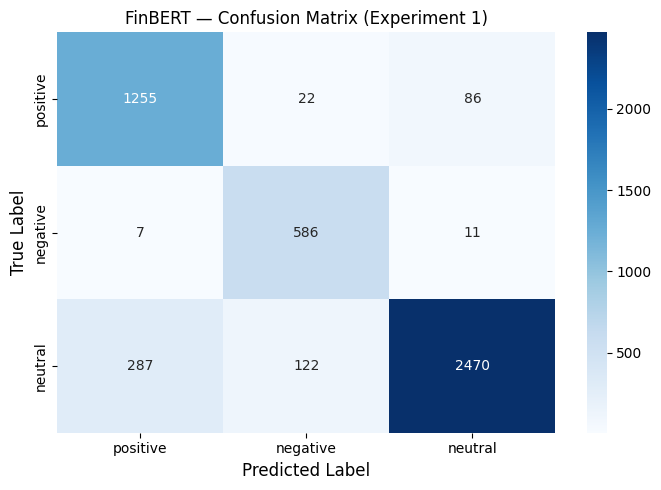

Confusion matrix saved to Google Drive.


In [9]:
# Confusion Matrix — FinBERT Experiment 1

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

labels_order = ["positive", "negative", "neutral"]

cm = confusion_matrix(true_labels, finbert_preds, labels=labels_order)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_order,
            yticklabels=labels_order)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("FinBERT — Confusion Matrix (Experiment 1)", fontsize=12)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Thesis_Data/fig_cm_finbert.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Confusion matrix saved to Google Drive.")